# Single vs Dual Score Matching — Anisotropic Diffusion Path

Direct analogue of `simple_example.ipynb` using an anisotropic diffusion path.

- **Same endpoints** as `simple_example`: GMM(σ=[1,4], p=0.5, d=1000) at t=0;
  isotropic N(0, t_max·I) source at t→∞.
- **Anisotropic path**: each sample gets a *random* partition of d dims into two groups
  (A, B) and two *independent* noise levels t_top, t_bot ~ UniformLog(t_min, t_max).
  Per-dim variance: `var_i = t_top` if i∈A, `t_bot` if i∈B.
- **`AnisoEBM`**: same MLP architecture as `SimpleEBM`; schedule embedding is 2-D
  `[log t_top, log t_bot]` (reduces to `[log t, log t]` = isotropic when t_top=t_bot).
  Sufficient statistics `(r_top², r_bot²)` replace the single ‖x‖.
- Training loop mirrors `simple_example` exactly; dual loss has one term per noise level.

In [27]:
%load_ext autoreload
%autoreload 2

import numpy as np
from matplotlib import pyplot as plt
import torch
from tqdm.notebook import tqdm

from main import *   # brings in EnergyModel, Reparameterization, SongUNet,
                     # noisy_batch, ModelInput, compute_metrics,
                     # apply_power_to_list_covariances,
                     # apply_inv_diff_tensor_from_list_covariances, etc.

# noise.s defaults to SignalShape(3) in noise.py — do NOT override it here.
# Images are (C,H,W) = 3-dimensional signals; overriding to SignalShape(1)
# caused network_forward to collapse (B,1,H,H) → (B·1·H, H).

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data & anisotropic noise mask

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Same data as simple_example ──
d = 1_000
sigma = torch.tensor([1, 4], device=device)   # GMM std devs
p     = torch.tensor([0.5, 0.5], device=device)

# ── Group sizes (equal split; random mask per sample is generated in training) ──
d_top = d // 2   # 500 dims — group A (t_top noise level)
d_bot = d // 2   # 500 dims — group B (t_bot noise level)

# ── Training data (same as simple_example: isotropic GMM) ──
n = 100_000
torch.manual_seed(0)
k = torch.multinomial(p, num_samples=n, replacement=True)
xs = torch.sqrt(sigma[k] ** 2)[:, None] * torch.randn((n, d), device=device)  # (N, d)
r  = torch.linalg.norm(xs, dim=-1)   # (N,)  Euclidean radius (for histogram)
print(f"xs: {xs.shape},  d_top={d_top}, d_bot={d_bot}")

xs: torch.Size([100000, 1000]),  d_top=500, d_bot=500


## True energy & normalization constant

$$E^*(y,\Sigma_t) = -\log\sum_k \pi_k\,\mathcal{N}(y;0,\sigma_k^2 I+\Sigma_t)$$

$$\log Z_t = \tfrac{1}{2}\sum_i \log(2\pi e\,\Sigma_{t,ii})$$

The **true normalization constant** is $C = \log Z_t - \mathbb{E}_{y\sim p_t}[E^*(y,\Sigma_t)]$, which should be $\approx 0$.

In [61]:
def true_aniso_energy(y_flat, var_per_dim, sigma, p):
    """Full anisotropic GMM energy E*(y, Σ_t).

    y_flat     : (B, d)
    var_per_dim: (B, d) or (d,) — per-dimension variance Σ_{t,ii}
    sigma      : (K,)  GMM std devs
    p          : (K,)  mixture weights
    Returns    : (B,) scalar energy
    """
    if var_per_dim.dim() == 1:
        var_per_dim = var_per_dim[None, :]          # (1, d)
    eff_v = sigma[None, :, None] ** 2 + var_per_dim[:, None, :]  # (B, K, d)
    quad  = 0.5 * (y_flat[:, None, :] ** 2 / eff_v).sum(-1)      # (B, K)
    lognr = 0.5 * torch.log(2 * np.pi * eff_v).sum(-1)           # (B, K)
    e_k   = quad + lognr - torch.log(p)[None, :]                  # (B, K)
    return -torch.logsumexp(-e_k, dim=-1)                         # (B,)

# ── Grid for plotting true energy (isotropic at t=0: var_per_dim = 0) ──
r0 = np.sqrt(d) * torch.linspace(0, 5, 500, device=device)
x_grid_plot = (r0[:, None] / np.sqrt(d)) * torch.ones(d, device=device)[None, :]  # (500, d)
var_zero     = torch.zeros(d, device=device)   # t=0
true_energy  = true_aniso_energy(x_grid_plot, var_zero, sigma, p)

# ── Sanity check: C = logZ - E[E*(y,t)] ≈ 0 at t_check ──
# At t_top = t_bot = t_check the distribution is isotropic N(0, t_check·I),
# so the isotropic trick logZ = d/2·log(2πe·t_check) is exact.
t_check = 1e3
n_mc    = 100_000
with torch.no_grad():
    y_iso_mc   = torch.randn(n_mc, d, device=device) * np.sqrt(t_check)
    var_iso_mc = torch.full((d,), t_check, device=device)
    avg_E      = true_aniso_energy(y_iso_mc, var_iso_mc, sigma, p).mean().item()
    logZ_check = d / 2 * np.log(2 * np.pi * np.e * t_check)
    print(f"True C at t={t_check:.0e} (isotropic, should be ≈0): {logZ_check - avg_E:.4f}")

True C at t=1e+03 (isotropic, should be ≈0): -0.0085


## Model — `AnisoEBM`

Analogue of `SimpleEBM` in `simple_example.ipynb`, but with two independent noise levels.

**Schedule embedding** (2-D): `[log(t_top + ε), log(t_bot + ε)]` — replaces the 1-D
`log(t + ε)` in `simple_example`; reduces to the isotropic case when `t_top = t_bot`.

**Sufficient statistics**: `(r_top², r_bot²)` where each group is determined by the
random mask `mask_batch` (generated per training batch). These are the exact sufficient
statistics of the true anisotropic GMM energy when the noise is two-block diagonal.

**Signature**: `forward(x_flat, t_top, t_bot, mask_batch)` — the mask is explicit so
different random partitions can be passed at each training step.

In [68]:
t_min_model = 1e-2

class AnisoEBM(nn.Module):
    """Energy model for anisotropic diffusion with two independent noise levels.

    forward(x_flat, t_top, t_bot, mask_batch) -> (B,) energy

    mask_batch : (B, d) bool — True for group A (t_top noise level)
    t_top, t_bot : (B,) noise level variances for each group

    Schedule embedding: [log(t_top + ε), log(t_bot + ε)]  (2-D, reduces to isotropic when equal)
    Sufficient statistics: r_top² = ‖x_A‖², r_bot² = ‖x_B‖²
    """
    def __init__(self, hidden_dim: int = 256, num_hidden_layers: int = 4):
        super().__init__()
        self.mlp = nn.Sequential(
            *[nn.Sequential(
                nn.Linear(2 if i == 0 else hidden_dim, hidden_dim),
                nn.GELU()
              ) for i in range(num_hidden_layers)],
            nn.Linear(hidden_dim, 6),   # a_top×2, a_bot×2, b×2
        )

    def forward_r(self, r_top_sq, r_bot_sq, t_top, t_bot):
        """r_top_sq, r_bot_sq, t_top, t_bot : (B,)  →  (B,) energy."""
        log_emb = torch.stack([
            torch.log(t_top + t_min_model),
            torch.log(t_bot + t_min_model),
        ], dim=-1)                           # (B, 2)
        coeffs = self.mlp(log_emb)          # (B, 6)
        a_top  = coeffs[:, :2]              # (B, 2)
        a_bot  = coeffs[:, 2:4]            # (B, 2)
        b      = d * coeffs[:, 4:]         # (B, 2) — scaled by d
        e = a_top * r_top_sq[:, None] + a_bot * r_bot_sq[:, None] + b
        return -torch.logsumexp(-e, dim=-1) # (B,)

    def forward(self, x_flat, t_top, t_bot, mask_batch):
        """
        x_flat     : (B, d)
        t_top      : (B,)   variance for group A dims
        t_bot      : (B,)   variance for group B dims
        mask_batch : (B, d) bool — True = group A
        """
        mf = mask_batch.float()
        r_top_sq = (x_flat * mf).pow(2).sum(-1)           # (B,)
        r_bot_sq = (x_flat * (1 - mf)).pow(2).sum(-1)     # (B,)
        return self.forward_r(r_top_sq, r_bot_sq, t_top, t_bot)

network_single = AnisoEBM().to(device)
network_dual   = AnisoEBM().to(device)
print(f"Parameters per model: {sum(q.numel() for q in network_single.parameters()):,}")

Parameters per model: 199,686


## Training loop

Mirrors `simple_example.ipynb` with the anisotropic generalisation:

- **Random mask per batch**: `perm = argsort(rand(B,d)); mask = perm < d_top` — each sample
  gets an independent random partition of d dims into groups A (t_top) and B (t_bot).
- **Two independent noise levels**: `t_top, t_bot ~ UniformLog(t_min, t_max)` per sample.
- **Per-dim variance**: `var_batch[i,j] = t_top[i] if mask[i,j] else t_bot[i]`
- **Noisy sample**: `y = x + sqrt(var_batch) · ε`
- **Whitened MSE**: `‖(x̂ − x) / sqrt(var_batch)‖² / d`  (M⁻¹-weighted)
- **Denoised estimate**: `x̂ = y − var_batch · ∇_y E`
- **Dual loss** (when `dual_objective=True`): two terms, one per noise level:
  - `noise_target_top = 1 − ‖ε_A‖² / d_top`  (≈0 in expectation)
  - `noise_target_bot = 1 − ‖ε_B‖² / d_bot`
  - `time_loss = ½[(target_top/2 − t_top·∂E/∂t_top / d_top)² + (target_bot/2 − t_bot·∂E/∂t_bot / d_bot)²]`
- All three gradients (∇_y E, ∂E/∂t_top, ∂E/∂t_bot) computed in **one autograd call**.

In [54]:
def get_energies(network, dual_objective, n_steps=50_000, lr=1e-4):
    t_min_tr, t_max_tr = 1e-2, 1e2

    optim = torch.optim.Adam(network.parameters(), lr=lr)
    dataset    = torch.utils.data.TensorDataset(xs)
    sampler    = InfiniteSampler(dataset, seed=0)
    dataloader = DataLoader(dataset, batch_size=512, sampler=sampler, num_workers=0)
    noise_sampler = UniformLog(
        min=NoiseLevel(dataset_info=None, variance=t_min_tr),
        max=NoiseLevel(dataset_info=None, variance=t_max_tr))

    losses = []
    network.train()
    for i, (x,) in enumerate(dataloader):
        if i >= n_steps:
            break
        if i % (n_steps // 10) == 0:
            lr_now = lr / (2 ** (i // (n_steps // 10)))
            for g in optim.param_groups:
                g['lr'] = lr_now

        x = x.to(device)   # (B, d)
        B = x.shape[0]

        # ── Two independent noise levels per sample ──
        t_top = noise_sampler.sample_noise_levels(torch.Size([B]), device=device).variance.detach()  # (B,)
        t_bot = noise_sampler.sample_noise_levels(torch.Size([B]), device=device).variance.detach()  # (B,)

        # ── Random mask: exactly d_top True entries per row ──
        perm       = torch.argsort(torch.rand(B, d, device=device), dim=-1)
        mask_batch = perm < d_top                                             # (B, d) bool

        # ── Per-dim variance (detached — used for noise scale and loss weight) ──
        mf        = mask_batch.float()
        var_batch = mf * t_top[:, None] + (1 - mf) * t_bot[:, None]         # (B, d)

        eps   = torch.randn_like(x)
        noise = eps * var_batch.sqrt()                                        # (B, d)

        # ── Autograd inputs ──
        y_req     = (x + noise).detach().requires_grad_(True)                # (B, d)
        t_top_req = t_top.clone().requires_grad_(True)                       # (B,)
        t_bot_req = t_bot.clone().requires_grad_(True)                       # (B,)

        E = network(y_req, t_top_req, t_bot_req, mask_batch)                 # (B,)

        # ── Compute all needed gradients in one pass ──
        if dual_objective:
            s_y, s_t_top, s_t_bot = torch.autograd.grad(
                E.sum(), [y_req, t_top_req, t_bot_req], create_graph=True)
        else:
            s_y = torch.autograd.grad(E.sum(), y_req, create_graph=True)[0]

        # ── Denoised estimate: x̂ = y − var · ∇_y E ──
        x_hat    = y_req - var_batch * s_y                                   # (B, d)

        # ── Whitened MSE: ‖(x̂ − x) / sqrt(var_batch)‖² / d ──
        mse_loss = ((x_hat - x) ** 2 / var_batch).mean(-1)                  # (B,)

        if dual_objective:
            # Noise components per group (using detached var for denominator)
            eps_top = eps * mf                                                # (B, d), zero outside A
            eps_bot = eps * (1 - mf)                                         # (B, d), zero outside B

            # Targets (≈0 in expectation for each group)
            noise_target_top = 1.0 - eps_top.pow(2).sum(-1) / d_top         # (B,)
            noise_target_bot = 1.0 - eps_bot.pow(2).sum(-1) / d_bot         # (B,)

            time_loss = 0.5 * (
                (noise_target_top / 2 - t_top_req * s_t_top / d_top) ** 2 +
                (noise_target_bot / 2 - t_bot_req * s_t_bot / d_bot) ** 2
            )                                                                 # (B,)
        else:
            time_loss = 0

        loss = (mse_loss + time_loss).mean()
        optim.zero_grad()
        loss.backward()
        optim.step()
        losses.append(loss.detach().cpu())

    # ── Normalization: t_top = t_bot = t_max → isotropic N(0, t_max·I) ──
    network.eval()
    with torch.no_grad():
        n_iso     = 50_000
        y_iso     = torch.randn(n_iso, d, device=device) * np.sqrt(t_max_tr)
        t_iso     = torch.full((n_iso,), t_max_tr, device=device)
        # Fixed mask for normalization (all rows: first d_top dims = group A)
        mask_iso  = torch.zeros(n_iso, d, dtype=torch.bool, device=device)
        mask_iso[:, :d_top] = True
        avg_e     = network(y_iso, t_iso, t_iso, mask_iso).mean().item()
        log_norm  = d / 2 * np.log(2 * np.pi * np.e * t_max_tr) - avg_e

        # ── Grid energies at t_top = t_bot = t_min (isotropic direction) ──
        x_grid    = (r0[:, None] / np.sqrt(d)) * torch.ones(d, device=device)[None, :]  # (500, d)
        t_grid    = torch.full((500,), t_min_tr, device=device)
        mask_grid = mask_iso[:500]
        e0        = network(x_grid, t_grid, t_grid, mask_grid) + log_norm

        # ── Data energies at t_top = t_bot = t_min ──
        n_sub      = 10_000
        mask_sub   = mask_iso[:n_sub]
        t_sub      = torch.full((n_sub,), t_min_tr, device=device)
        e_data     = network(xs[:n_sub], t_sub, t_sub, mask_sub) + log_norm

    return torch.stack(losses), log_norm, e0, e_data

## Training loop — Σ_t-weighted dual loss (matches main codebase)

Same as above, but the dual loss uses **per-dimension residuals** (mean of squares)
instead of a **squared mean residual**, matching the Frobenius-norm weighting in `compute_metrics`.

For group A, the per-dimension residual is:
$$r_j = t_A\,\partial_{t_A}U_\theta - \frac{1 - \varepsilon_j^2}{2}, \quad j \in A$$

and the loss is $\frac{1}{d}\sum_{j\in A} r_j^2$ (plus the analogous term for B).

The original `get_energies` uses $\frac{1}{d_A^2}\left(\sum_j r_j\right)^2$ (squared sum).
By Jensen/Cauchy–Schwarz the per-dim version is always ≥ the squared-sum version,
and it matches the diagonal contribution of $\frac{1}{d}\|\Sigma_t(\partial_{\Sigma_t}U - \phi^{-1}(z))\|_F^2$
from the main codebase (off-diagonal terms are model-independent and do not affect gradients).

In [70]:
def get_energies_weighted(network, dual_objective, n_steps=50_000, lr=1e-4):
    """Same as get_energies, but with Σ_t-weighted dual loss (per-dim residuals).

    Dual loss change:
        Original : (noise_target / 2 - t * s_t / d_group)²          [squared mean]
        Here     : mean_j[ (t * s_t - (1 - ε_j²) / 2)² ] / d        [mean of squares]

    The latter matches the diagonal contribution of the main codebase's
        noise_loss = ‖Σ_t (∂_Σt U - φ⁻¹(z))‖²_F / d
    """
    t_min_tr, t_max_tr = 1e-2, 1e2

    optim = torch.optim.Adam(network.parameters(), lr=lr)
    dataset    = torch.utils.data.TensorDataset(xs)
    sampler    = InfiniteSampler(dataset, seed=0)
    dataloader = DataLoader(dataset, batch_size=512, sampler=sampler, num_workers=0)
    noise_sampler = UniformLog(
        min=NoiseLevel(dataset_info=None, variance=t_min_tr),
        max=NoiseLevel(dataset_info=None, variance=t_max_tr))

    losses = []
    network.train()
    for i, (x,) in enumerate(dataloader):
        if i >= n_steps:
            break
        if i % (n_steps // 10) == 0:
            lr_now = lr / (2 ** (i // (n_steps // 10)))
            for g in optim.param_groups:
                g['lr'] = lr_now

        x = x.to(device)
        B = x.shape[0]

        t_top = noise_sampler.sample_noise_levels(torch.Size([B]), device=device).variance.detach()
        t_bot = noise_sampler.sample_noise_levels(torch.Size([B]), device=device).variance.detach()

        perm       = torch.argsort(torch.rand(B, d, device=device), dim=-1)
        mask_batch = perm < d_top                                    # (B, d) bool
        mf         = mask_batch.float()
        var_batch  = mf * t_top[:, None] + (1 - mf) * t_bot[:, None]

        eps   = torch.randn_like(x)
        noise = eps * var_batch.sqrt()

        y_req     = (x + noise).detach().requires_grad_(True)
        t_top_req = t_top.clone().requires_grad_(True)
        t_bot_req = t_bot.clone().requires_grad_(True)

        E = network(y_req, t_top_req, t_bot_req, mask_batch)

        if dual_objective:
            s_y, s_t_top, s_t_bot = torch.autograd.grad(
                E.sum(), [y_req, t_top_req, t_bot_req], create_graph=True)
        else:
            s_y = torch.autograd.grad(E.sum(), y_req, create_graph=True)[0]

        x_hat    = y_req - var_batch * s_y
        mse_loss = ((x_hat - x) ** 2 / var_batch).mean(-1)

        if dual_objective:
            # ── Per-dimension residual: r_j = t * s_t - (1 - ε_j²) / 2 ──
            # Group A (mask = True): use t_top_req; group B: use t_bot_req.
            # s_t_top / s_t_bot are (B,) scalars → broadcast to (B, d).
            r_top = t_top_req[:, None] * s_t_top[:, None] - (1 - eps.pow(2)) / 2  # (B, d)
            r_bot = t_bot_req[:, None] * s_t_bot[:, None] - (1 - eps.pow(2)) / 2  # (B, d)

            # Sum squared residuals over the respective group dims, divide by d.
            time_loss = (
                (r_top * mf).pow(2).sum(-1) +          # Σ_{j∈A} r_j² / d
                (r_bot * (1 - mf)).pow(2).sum(-1)      # Σ_{j∈B} r_j² / d
            ) / d                                       # (B,)
        else:
            time_loss = 0

        loss = (mse_loss + time_loss).mean()
        optim.zero_grad()
        loss.backward()
        optim.step()
        losses.append(loss.detach().cpu())

    # ── Normalization (identical to get_energies) ──
    network.eval()
    with torch.no_grad():
        n_iso    = 50_000
        y_iso    = torch.randn(n_iso, d, device=device) * np.sqrt(t_max_tr)
        t_iso    = torch.full((n_iso,), t_max_tr, device=device)
        mask_iso = torch.zeros(n_iso, d, dtype=torch.bool, device=device)
        mask_iso[:, :d_top] = True
        avg_e    = network(y_iso, t_iso, t_iso, mask_iso).mean().item()
        log_norm = d / 2 * np.log(2 * np.pi * np.e * t_max_tr) - avg_e

        x_grid   = (r0[:, None] / np.sqrt(d)) * torch.ones(d, device=device)[None, :]
        t_grid   = torch.full((500,), t_min_tr, device=device)
        e0       = network(x_grid, t_grid, t_grid, mask_iso[:500]) + log_norm

        n_sub    = 10_000
        t_sub    = torch.full((n_sub,), t_min_tr, device=device)
        e_data   = network(xs[:n_sub], t_sub, t_sub, mask_iso[:n_sub]) + log_norm

    return torch.stack(losses), log_norm, e0, e_data

## Run

In [71]:
import os; os.makedirs('outputs', exist_ok=True)

# Uncomment to train:
losses_dual,   norm_dual,   e_dual_grid,   e_dual_data   = get_energies_weighted(network_dual,   dual_objective=True)
losses_single, norm_single, e_single_grid, e_single_data = get_energies_weighted(network_single, dual_objective=False)
torch.save((norm_dual, e_dual_grid, e_dual_data, norm_single, e_single_grid, e_single_data),
           'outputs/single_vs_dual_sm_aniso.pt')

# # Or load:
# norm_dual, e_dual_grid, e_dual_data, norm_single, e_single_grid, e_single_data = \
#     torch.load('outputs/single_vs_dual_sm_aniso.pt')

## Normalization constant C(t) across the full noise range

$$C(t) = \log Z_t - \mathbb{E}_{y\sim p_t}[E_\theta(y,\Sigma_t)]$$

Dual SM forces $C(t)$ to be **flat** (constant in $t$); Single SM lets it drift.

In [72]:
# Verify normalization against the true energy on held-out data (t=0, var_per_dim=0).
n_check = 10_000
with torch.no_grad():
    k_ch  = torch.multinomial(p, n_check, replacement=True)
    x_ch  = sigma[k_ch, None] * torch.randn(n_check, d, device=device)
    var_zero_ch = torch.zeros(d, device=device)
    true_E_ch   = true_aniso_energy(x_ch, var_zero_ch, sigma, p).mean().item()

true_entropy = true_aniso_energy(xs[:n_check], var_zero_ch, sigma, p).mean().item()
cst_single   = true_entropy - e_single_data.mean().item()   # offset to align single SM

print(f"norm_dual   = {norm_dual:.4f}")
print(f"norm_single = {norm_single:.4f}")
print(f"true H(p)   = {-true_entropy:.4f}")
print(f"Single SM offset (for adjusted curve): {cst_single:.4f}")

norm_dual   = 2878.4960
norm_single = 3236.1518
true H(p)   = -2107.5422
Single SM offset (for adjusted curve): -1576.0325


## Energy comparison along M-weighted radial direction

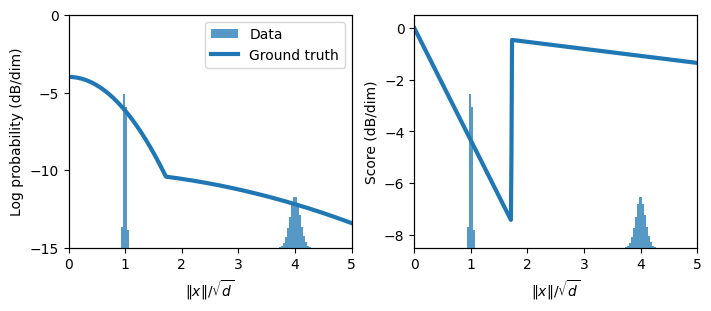

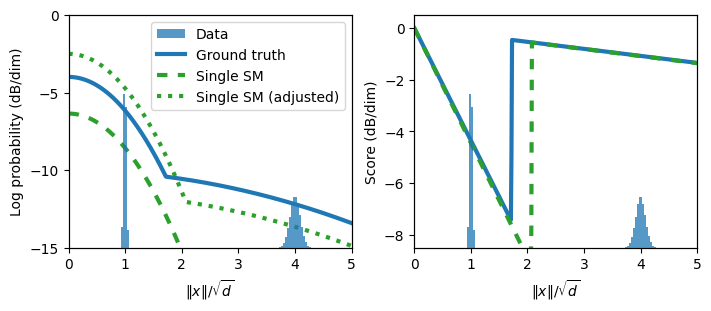

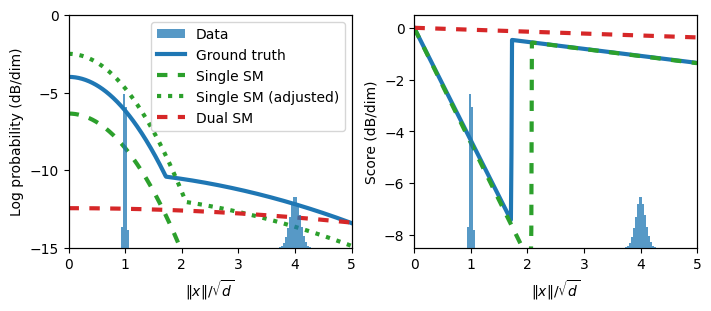

In [73]:
true_color   = "tab:blue"
single_color = "tab:green"
dual_color   = "tab:red"
dashes = (0, (2.5, 2.5))
from plotting import plot_lines

conv = lambda e: -10 * e / (d * np.log(10))   # energy → dB/dim

for i in range(3):
    fig, axs = plt.subplots(figsize=(7, 3), ncols=2, layout="constrained")

    # ── Left: energy ──
    plt.sca(axs[0])
    plot_lines(conv(true_energy), x=r0 / np.sqrt(d), color=true_color,
               has_fig=True, grid=False, label="Ground truth", linewidth=3)
    if i >= 1:
        plot_lines(conv(e_single_grid) + 3, x=r0 / np.sqrt(d), color=single_color,
                   has_fig=True, grid=False, linestyle=dashes, label="Single SM", linewidth=3)
        plot_lines(conv(e_single_grid + cst_single), x=r0 / np.sqrt(d), color=single_color,
                   has_fig=True, grid=False, linestyle=":", label="Single SM (adjusted)", linewidth=3)
    if i >= 2:
        plot_lines(conv(e_dual_grid), x=r0 / np.sqrt(d), color=dual_color,
                   has_fig=True, grid=False, linestyle=dashes, label="Dual SM", linewidth=3)
    plt.xlim(0, 5); plt.ylim(-15, 0); plt.yticks([0, -5, -10, -15])
    plt.xlabel(r"$\|x\|/\sqrt{d}$"); plt.ylabel("Log probability (dB/dim)")
    twin = plt.twinx()
    plt.hist(r.cpu() / np.sqrt(d), density=True, bins=100,
             color=true_color, zorder=-1, alpha=0.75, label="Data", rasterized=True)
    plt.ylim(0, 10)
    plt.tick_params(axis='y', which='both', right=False, labelright=False)
    lines, labels   = axs[0].get_legend_handles_labels()
    lines2, labels2 = twin.get_legend_handles_labels()
    plt.legend(lines2 + lines, labels2 + labels, loc="upper right")

    # ── Right: score (numerical derivative of energy) ──
    plt.sca(axs[1])
    delta = (r0[1] - r0[0]) / np.sqrt(d)
    r2    = (r0[1:] + r0[:-1]) / 2
    diff  = lambda e: (e[1:] - e[:-1]) / delta
    plot_lines(diff(conv(true_energy)), x=r2 / np.sqrt(d), color=true_color,
               has_fig=True, grid=False, linewidth=3)
    if i >= 1:
        plot_lines(diff(conv(e_single_grid)), x=r2 / np.sqrt(d), color=single_color,
                   has_fig=True, grid=False, linestyle=dashes, linewidth=3)
    if i >= 2:
        plot_lines(diff(conv(e_dual_grid)), x=r2 / np.sqrt(d), color=dual_color,
                   has_fig=True, grid=False, linestyle=dashes, linewidth=3)
    plt.xlim(0, 5); plt.ylim(-8.5, 0.5)
    plt.xlabel(r"$\|x\|/\sqrt{d}$"); plt.ylabel(r"Score (dB/dim)")
    plt.twinx()
    plt.hist(r.cpu() / np.sqrt(d), density=True, bins=100,
             color=true_color, zorder=-1, alpha=0.75, rasterized=True)
    plt.ylim(0, 10)
    plt.tick_params(axis='y', which='both', right=False, labelright=False)

    plt.savefig(f"outputs/single_vs_dual_sm_aniso_step{i}.pdf",
                transparent=True, bbox_inches="tight", pad_inches=0, dpi=600)
    plt.show()